In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [ ]:
# Load dataset (top 10,000 most frequent words)
max_features = 10000
max_len = 100

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

# Pad sequences to same length
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test  = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Train shape:", x_train.shape)

Train shape: (25000, 100)


In [ ]:
def build_rnn():
    model = keras.Sequential([
        layers.Embedding(max_features, 128, input_length=max_len),
        layers.SimpleRNN(64),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

In [ ]:
def build_lstm():
    model = keras.Sequential([
        layers.Embedding(max_features, 128, input_length=max_len),
        layers.LSTM(64),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

In [ ]:
def build_gru():
    model = keras.Sequential([
        layers.Embedding(max_features, 128, input_length=max_len),
        layers.GRU(64),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

In [ ]:
def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

In [ ]:
epochs = 5
batch_size = 256

# RNN
model_rnn = build_rnn()
compile_model(model_rnn)
hist_rnn = model_rnn.fit(x_train, y_train,
                         epochs=epochs,
                         batch_size=batch_size,
                         validation_split=0.2)

# LSTM
model_lstm = build_lstm()
compile_model(model_lstm)
hist_lstm = model_lstm.fit(x_train, y_train,
                           epochs=epochs,
                           batch_size=batch_size,
                           validation_split=0.2)

# GRU
model_gru = build_gru()
compile_model(model_gru)
hist_gru = model_gru.fit(x_train, y_train,
                         epochs=epochs,
                         batch_size=batch_size,
                         validation_split=0.2)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.6980 - loss: 0.5631 - val_accuracy: 0.7978 - val_loss: 0.4456
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.8721 - loss: 0.3131 - val_accuracy: 0.8278 - val_loss: 0.3924
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.9388 - loss: 0.1726 - val_accuracy: 0.8368 - val_loss: 0.4279
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.9806 - loss: 0.0711 - val_accuracy: 0.7958 - val_loss: 0.5197
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - accuracy: 0.9948 - loss: 0.0257 - val_accuracy: 0.8168 - val_loss: 0.5577
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 35s 396ms/step - accuracy: 0.7491 - loss: 0.5076 - val_accuracy: 0.8340 - val_loss: 0.3641
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 364ms/step - accuracy: 0.8843 - loss: 0.2837 - val_accuracy: 0.8460 - val_loss: 0.3656
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 383ms/step - accuracy: 0.9233 - loss: 0.2047 - val_accuracy: 0.

In [ ]:
model_rnn.summary()
model_lstm.summary()
model_gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,877,253 (14.79 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,951,941 (15.08 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,634,628 (10.05 MB)

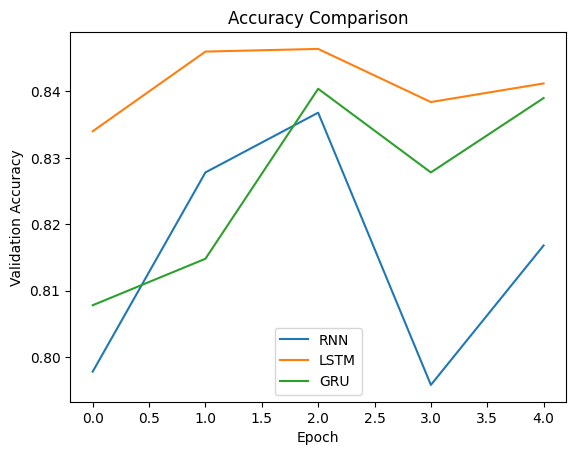

In [ ]:
plt.plot(hist_rnn.history["val_accuracy"], label="RNN")
plt.plot(hist_lstm.history["val_accuracy"], label="LSTM")
plt.plot(hist_gru.history["val_accuracy"], label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

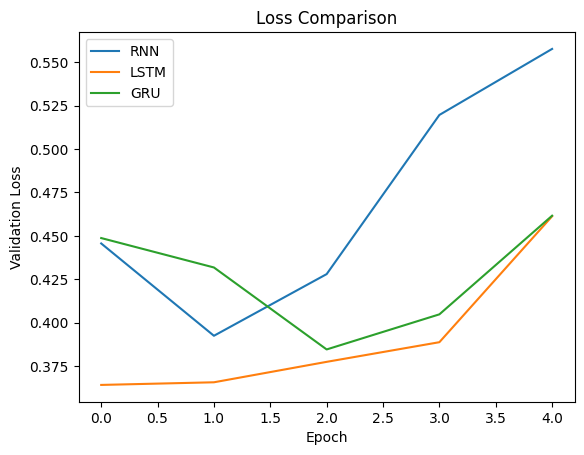

In [ ]:
plt.plot(hist_rnn.history["val_loss"], label="RNN")
plt.plot(hist_lstm.history["val_loss"], label="LSTM")
plt.plot(hist_gru.history["val_loss"], label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Loss Comparison")
plt.legend()
plt.show()

In [ ]:
print("\n Accuracy:")

print("\nRNN Train Acc:",
      model_rnn.evaluate(x_train, y_train, verbose=0)[1])
print("RNN Test Acc:",
      model_rnn.evaluate(x_test, y_test, verbose=0)[1])


print("\nLSTM Train Acc:",
      model_lstm.evaluate(x_train, y_train, verbose=0)[1])
print("LSTM Test Acc:",
      model_lstm.evaluate(x_test, y_test, verbose=0)[1])


print("\nGRU Train Acc:",
      model_gru.evaluate(x_train, y_train, verbose=0)[1])
print("GRU Test Acc:",
      model_gru.evaluate(x_test, y_test, verbose=0)[1])


 Accuracy:

RNN Train Acc: 0.9625999927520752
RNN Test Acc: 0.8094000220298767

LSTM Train Acc: 0.9515200257301331
LSTM Test Acc: 0.8362799882888794

GRU Train Acc: 0.9493200182914734
GRU Test Acc: 0.8327599763870239
